In [1]:
# Se importan todas las librerías necesarias
import pandas as pd
import seaborn as sns
import numpy as np  
from matplotlib import pyplot as plt
import pickle

# Importante poner para que se muestren los gráficos
%matplotlib inline

# Semilla que se usará siempre para garantizar reproducibilidad
semilla = 123

# Directorio con los ficheros
dir_datasets = "./VulkanSimTrain/"

In [2]:
nombres_escenas = ["BATH", "BUNNY", "CAR", "CHSNT", "CRNVL", "FOX", "FRST", "LANDS", "PARK", "PARTY", "REF", "ROBOT", "SHIP", "SPNZA", "SPRNG", "WKND"]

datos = dict()

for nombre in nombres_escenas:
    datos[nombre] = pd.read_csv(dir_datasets+nombre+"-frame0.txt",sep=",",header=None,names=["ID","Cycle","Address","IP","Cache_hit"])


In [3]:
for nombre in nombres_escenas:
    print(f"Escena: {nombre}")
    print()
    print(datos[nombre].head())
    print("-"*80)

Escena: BATH

   ID  Cycle    Address     IP  Cache_hit
0   0  35655   c6abf000   1bc8          0
1   1  35679   c6abf000   1bc8          0
2   2  35900   c6abf000   1bc8          1
3   3  35901   c6abf000   1bc8          1
4   4  35912   c6abf000   1bc8          1
--------------------------------------------------------------------------------
Escena: BUNNY

   ID  Cycle    Address     IP  Cache_hit
0   0  36870   c2333b00   1bc8          0
1   1  36894   c2333b00   1bc8          0
2   2  38671   c2333b00   1bc8          1
3   3  38683   c2333b00   1bc8          1
4   4  38958   c2333b00   1bc8          0
--------------------------------------------------------------------------------
Escena: CAR

   ID  Cycle     Address     IP  Cache_hit
0   0  35698   1f049f900   1bc8          0
1   1  35722   1f049f900   1bc8          0
2   2  36087   1f049f900   1bc8          1
3   3  36111   1f049f900   1bc8          1
4   4  36220   1f049f900   1bc8          1
----------------------------------

In [4]:
for nombre in nombres_escenas:
    print(f"Escena: {nombre}")
    print()
    print(datos[nombre].dtypes)
    print("-"*80)

Escena: BATH

ID            int64
Cycle         int64
Address      object
IP           object
Cache_hit     int64
dtype: object
--------------------------------------------------------------------------------
Escena: BUNNY

ID            int64
Cycle         int64
Address      object
IP           object
Cache_hit     int64
dtype: object
--------------------------------------------------------------------------------
Escena: CAR

ID            int64
Cycle         int64
Address      object
IP           object
Cache_hit     int64
dtype: object
--------------------------------------------------------------------------------
Escena: CHSNT

ID            int64
Cycle         int64
Address      object
IP           object
Cache_hit     int64
dtype: object
--------------------------------------------------------------------------------
Escena: CRNVL

ID            int64
Cycle         int64
Address      object
IP           object
Cache_hit     int64
dtype: object
----------------------------------

In [5]:
# Se pasa la columna Address de hexadecimal a decimal
for nombre in nombres_escenas:
    print("Escena",nombre)
    print()
    datos[nombre]["Address"] = datos[nombre]["Address"].apply(lambda x: int(str(x), 16))
    print("-"*80)

Escena BATH

--------------------------------------------------------------------------------
Escena BUNNY

--------------------------------------------------------------------------------
Escena CAR

--------------------------------------------------------------------------------
Escena CHSNT

--------------------------------------------------------------------------------
Escena CRNVL

--------------------------------------------------------------------------------
Escena FOX

--------------------------------------------------------------------------------
Escena FRST

--------------------------------------------------------------------------------
Escena LANDS

--------------------------------------------------------------------------------
Escena PARK

--------------------------------------------------------------------------------
Escena PARTY

--------------------------------------------------------------------------------
Escena REF

---------------------------------------------

In [6]:
# Se crea la columna Block_address dividiendo los valores de la
# columna Address entre 128
for nombre in nombres_escenas:
    print("Escena",nombre)
    print()
    datos[nombre]['Block_address'] = datos[nombre]['Address'].apply(lambda x: x//128)
    print("-"*80)


Escena BATH

--------------------------------------------------------------------------------
Escena BUNNY

--------------------------------------------------------------------------------
Escena CAR

--------------------------------------------------------------------------------
Escena CHSNT

--------------------------------------------------------------------------------
Escena CRNVL

--------------------------------------------------------------------------------
Escena FOX

--------------------------------------------------------------------------------
Escena FRST

--------------------------------------------------------------------------------
Escena LANDS

--------------------------------------------------------------------------------
Escena PARK

--------------------------------------------------------------------------------
Escena PARTY

--------------------------------------------------------------------------------
Escena REF

---------------------------------------------

In [7]:
# Se pasa la columna IP de hexadecimal a decimal, asignando -1 a los valores ffffffffffffffff
for nombre in nombres_escenas:
    print("Escena",nombre)
    print()
    datos[nombre]['IP'] = datos[nombre]['IP'].apply(lambda x: int(x, 16) if x != "ffffffffffffffff" else -1)
    print("-"*80)

Escena BATH

--------------------------------------------------------------------------------
Escena BUNNY

--------------------------------------------------------------------------------
Escena CAR

--------------------------------------------------------------------------------
Escena CHSNT

--------------------------------------------------------------------------------
Escena CRNVL

--------------------------------------------------------------------------------
Escena FOX

--------------------------------------------------------------------------------
Escena FRST

--------------------------------------------------------------------------------
Escena LANDS

--------------------------------------------------------------------------------
Escena PARK

--------------------------------------------------------------------------------
Escena PARTY

--------------------------------------------------------------------------------
Escena REF

---------------------------------------------

In [8]:
# Se crea la columna Page_address dividiendo los valores de la
# columna Address entre 4096
for nombre in nombres_escenas:
    print("Escena",nombre)
    print()
    datos[nombre]['Page_address'] = datos[nombre]['Address'].apply(lambda x: x//4096)
    print("-"*80)

Escena BATH

--------------------------------------------------------------------------------
Escena BUNNY

--------------------------------------------------------------------------------
Escena CAR

--------------------------------------------------------------------------------
Escena CHSNT

--------------------------------------------------------------------------------
Escena CRNVL

--------------------------------------------------------------------------------
Escena FOX

--------------------------------------------------------------------------------
Escena FRST

--------------------------------------------------------------------------------
Escena LANDS

--------------------------------------------------------------------------------
Escena PARK

--------------------------------------------------------------------------------
Escena PARTY

--------------------------------------------------------------------------------
Escena REF

---------------------------------------------

In [9]:
datos["ROBOT"].head()

,ID,Cycle,Address,IP,Cache_hit,Block_address,Page_address
0,0,34605,8859649280,7112,0,69216010,2163000
1,1,34617,8859649280,7112,0,69216010,2163000
2,2,34990,8859649280,7112,1,69216010,2163000
3,3,35002,8859649280,7112,1,69216010,2163000
4,4,36965,8859649280,7112,1,69216010,2163000


In [10]:
datos["ROBOT"].dtypes

ID               int64
Cycle            int64
Address          int64
IP               int64
Cache_hit        int64
Block_address    int64
Page_address     int64
dtype: object

In [11]:
datos["ROBOT"].describe()

,ID,Cycle,Address,IP,Cache_hit,Block_address,Page_address
count,2.849572e+07,2.849572e+07,2.849572e+07,28495718.0,2.849572e+07,2.849572e+07,2.849572e+07
mean,1.424786e+07,1.929569e+07,6.157825e+09,7112.0,3.737972e-01,4.810800e+07,1.503375e+06
std,8.226005e+06,1.120788e+07,1.160418e+09,0.0,4.838108e-01,9.065762e+06,2.833051e+05
min,0.000000e+00,3.460500e+04,6.706499e+08,7112.0,0.000000e+00,5.239452e+06,1.637320e+05
25%,7.123929e+06,9.583870e+06,5.574011e+09,7112.0,0.000000e+00,4.354696e+07,1.360842e+06
50%,1.424786e+07,1.929918e+07,6.140094e+09,7112.0,0.000000e+00,4.796949e+07,1.499046e+06
75%,2.137179e+07,2.895864e+07,6.827944e+09,7112.0,1.000000e+00,5.334332e+07,1.666978e+06
max,2.849572e+07,4.109267e+07,8.859686e+09,7112.0,1.000000e+00,6.921630e+07,2.163009e+06


In [13]:
historias = [1,2,3,4,5,6,7,8,9,10]

# La clave es la historia. El valor es una lista con los
# porcentajes para cada escena
porcentaje_predicciones_correctas = dict()

for historia in historias:
    print(f"HISTORIA {historia}")
    print("="*20)

    porcentaje_predicciones_correctas[historia] = []

    for escena in nombres_escenas:
        # La PTT ahora no guarda correspondencias entre
        # páginas pasadas y la página futura. Ahora guarda
        # correspondencias entre deltas pasados y el delta futuro
        ptt = dict()

        k = 5

        predicciones_correctas = 0
        predicciones_erroneas = 0

        for i in range(historia,len(datos[escena])-k):
            #print("-"*30)
            #print(f"Iteración {i}")

            # Estas son las páginas que se tendrán en cuenta para calcular los deltas
            paginas_historia = tuple(datos[escena]["Page_address"][i-historia:i+1])

            #print(f"Páginas historia: {paginas_historia}")

            # Estos son los deltas entre páginas
            deltas = []

            for j in range(1,len(paginas_historia)):
                pagina_actual = paginas_historia[j]
                pagina_pasada = paginas_historia[j-1]
                delta = pagina_actual-pagina_pasada
                deltas.append(delta)
            
            # La lista de deltas se pasa a una tupla para poder usarla
            # como clave en el diccionario
            deltas = tuple(deltas)
            #print(f"Deltas: {deltas}")

            if deltas in ptt:
                # Si hay coincidencia, se utiliza el delta predicho
                # que hay en la PTT
                delta_predicho = ptt[deltas]
            else:
                # Si no hay coincidencia, se considera que se
                # seguirá en la misma página (delta 0)
                delta_predicho = 0
            
            #print(f"Delta predicho: {delta_predicho}")

            # Se calcula el delta real
            delta_real = (datos[escena]["Page_address"][i+k] - datos[escena]["Page_address"][i])

            #print(f"Delta real: {delta_real}")

            # Si el delta entre la página que hay 5 accesos después y la página actual es correcto,
            # se aumenta el contador de predicciones correctas. Si no, se aumenta el contador de
            # predicciones erróneas
            if delta_real == delta_predicho:
                predicciones_correctas+=1
            else:
                predicciones_erroneas+=1

            # Independientemente de lo que haya ocurrido, se actualiza la PTT con la
            # información del delta 
            ptt[deltas] = delta_real

        print(f"Predicciones correctas en la escena {escena}: {predicciones_correctas} ({100*predicciones_correctas/(predicciones_correctas+predicciones_erroneas)}%)")
        porcentaje_predicciones_correctas[historia].append(str(100*predicciones_correctas/(predicciones_correctas+predicciones_erroneas)))
    print()

HISTORIA 1


KeyboardInterrupt: 

In [ ]:
with open('porcentaje_predicciones_correctas.p', 'wb') as fp:
    pickle.dump(porcentaje_predicciones_correctas, fp, protocol=pickle.HIGHEST_PROTOCOL)

In [3]:
with open('porcentaje_predicciones_correctas.p', 'rb') as fp:
    porcentaje_predicciones_correctas = pickle.load(fp)

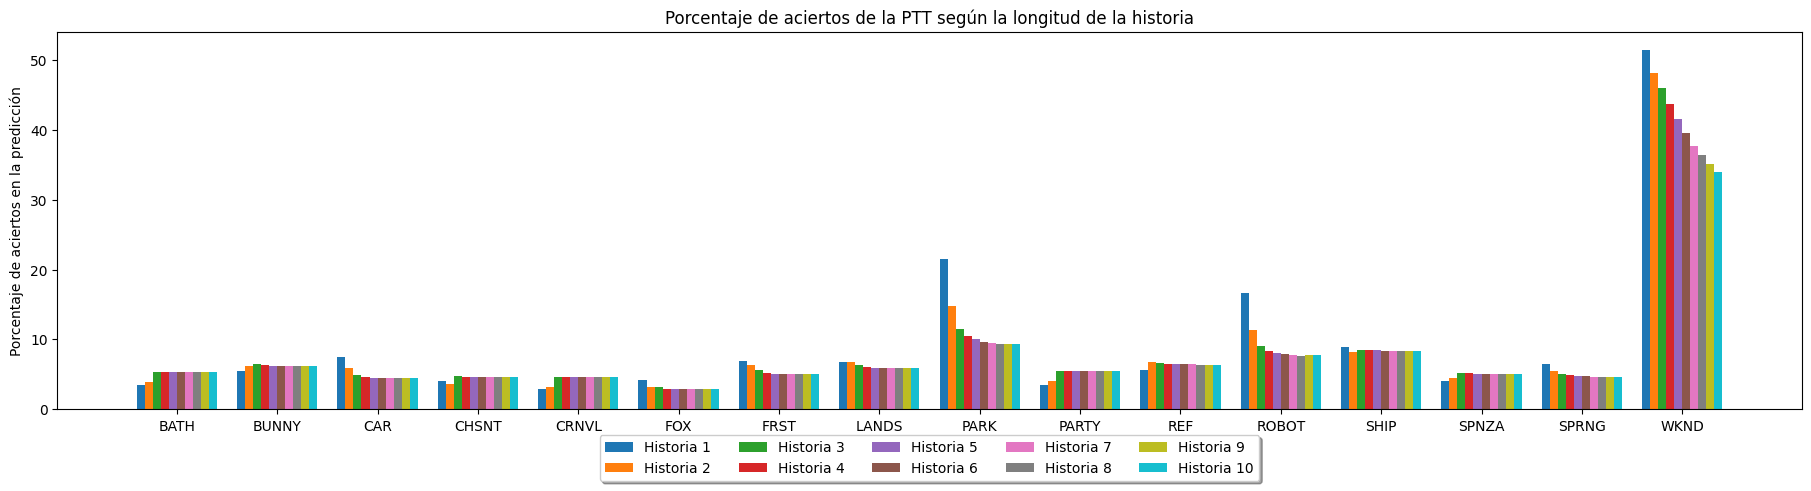

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Localización de cada etiqueta
x = np.arange(len(nombres_escenas))

# Anchura de las barras
width = 0.08

multiplier = 0

fig, ax = plt.subplots(layout='constrained')

fig.set_figwidth(18)

for historia, medidas in porcentaje_predicciones_correctas.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, medidas, width, label=f"Historia {historia}")
    #ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Porcentaje de aciertos en la predicción')
ax.set_title('Porcentaje de aciertos de la PTT según la longitud de la historia')
ax.set_xticks(x + width*4.5, nombres_escenas)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5)

plt.show()